In [2]:
from libraries import*
from simulation_B_spin_modified import  wX, Ispin, w0, delta_ppm, eta, CQ_M, Qeta, alpha, beta, gamma, QPAS, Siso_ppm, Siso, QXG, CsaQXG, AcsQXG
from functions import fourier3, fourier5, fourier6, Rabc, Quad, ChemShift, AntiShift
from scipy.interpolate import make_interp_spline
import sympy as sym
from sympy import *
B0 = 14.1 #magnetic field used
w0 = 192.55 #input for 11B 
# print(w0)
wX = w0*10**6 #actual freq in Hz
Ispin = 3/2 #spin of 11B
#(https://pages.nyu.edu/jerschow/NMRmap/NMRmap_deployed.html)

Welcome to JupyROOT 6.26/06
iminuit version: 2.17.0


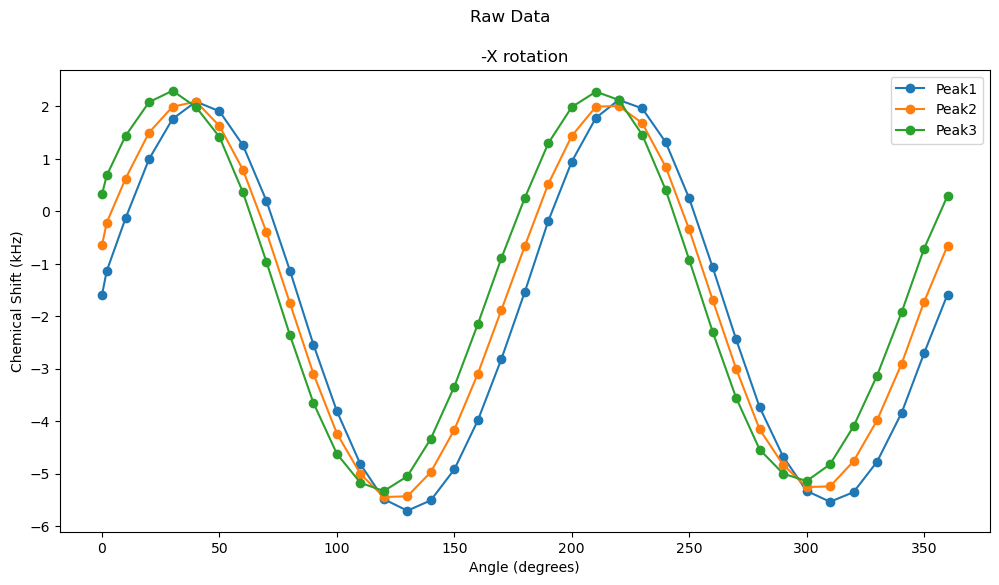

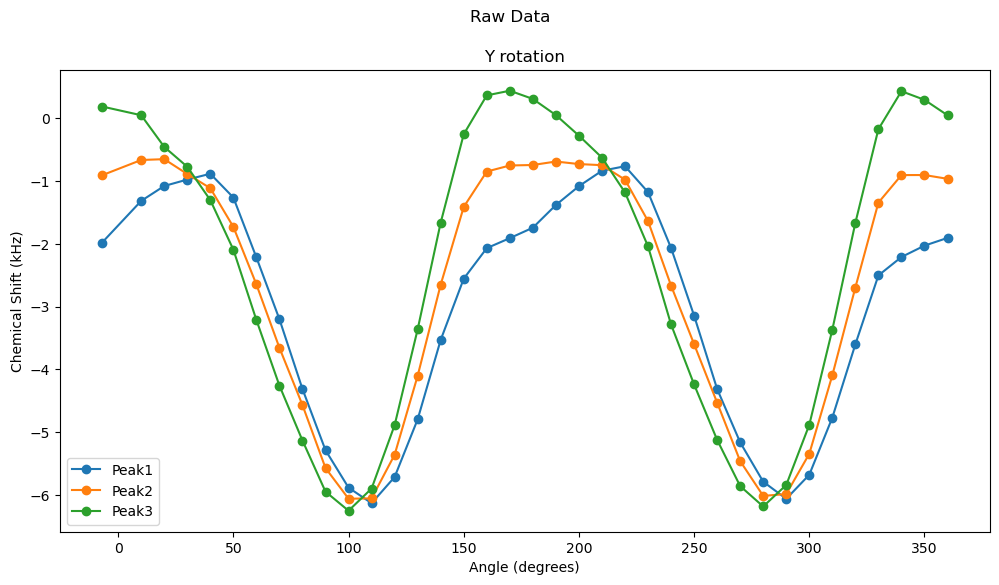

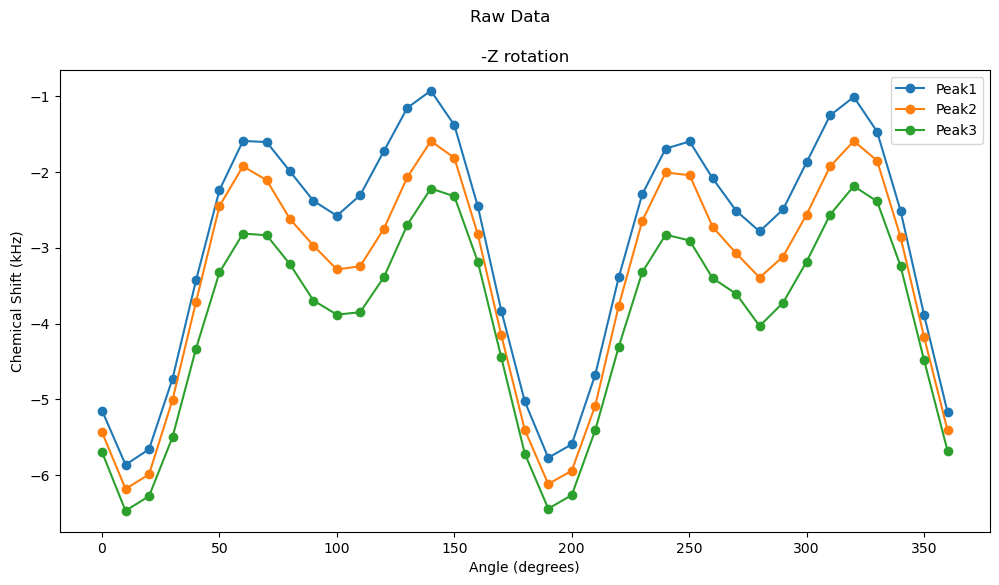

In [3]:
titles = ['-X rotation', 'Y rotation', '-Z rotation']
df = [0]*3

    
df[0] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(-)8HQ_X_Rot', skiprows=[1])
df[1] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(-)8HQ_Y_Rot', skiprows=[1])
df[2] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(-)8HQ_Z_Rot', skiprows=[1])
for i in range(3):

    df[i].Cluster1Peak0 = df[i].Cluster1Peak0*w0/1000
    df[i].Cluster1Peak1 = df[i].Cluster1Peak1*w0/1000
    df[i].Cluster1Peak2 = df[i].Cluster1Peak2*w0/1000

    # print(df[i].Cluster1Peak1)
    plt.figure(figsize=(12, 6))


    plt.plot(df[i].Angle, df[i].Cluster1Peak0, label = 'Peak1', marker='o')
    plt.plot(df[i].Angle, df[i].Cluster1Peak1, label = 'Peak2', marker='o')
    plt.plot(df[i].Angle, df[i].Cluster1Peak2, label = 'Peak3', marker='o')
    plt.suptitle('Raw Data')
    plt.xlabel('Angle (degrees)')
    plt.ylabel('Chemical Shift (kHz)')
    plt.title(titles[i])
    plt.legend()
    plt.show()

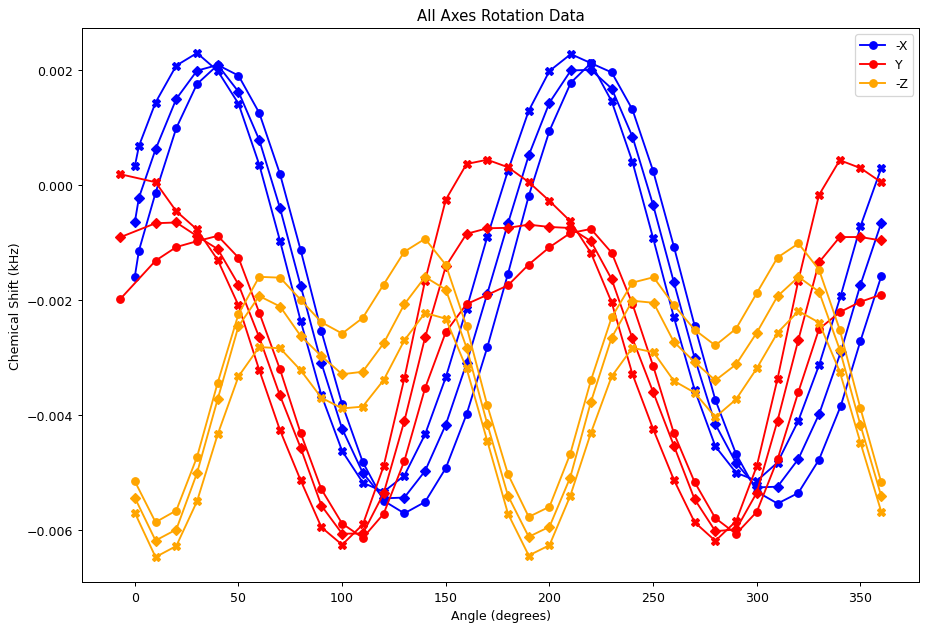

In [4]:
plt.figure(figsize = (12,8), dpi = 90)

plt.plot(df[0].Angle, df[0].Cluster1Peak0/1000,'-bo' ,label = '-X')
plt.plot(df[0].Angle, df[0].Cluster1Peak1/1000,'-bD')
plt.plot(df[0].Angle, df[0].Cluster1Peak2/1000, '-bX')

plt.plot(df[1].Angle, df[1].Cluster1Peak0/1000,'-ro' ,label = 'Y')
plt.plot(df[1].Angle, df[1].Cluster1Peak1/1000,'-rD')
plt.plot(df[1].Angle, df[1].Cluster1Peak2/1000, '-rX')

plt.plot(df[2].Angle, df[2].Cluster1Peak0/1000, linestyle='-', marker='o', color = 'orange',label = '-Z')
plt.plot(df[2].Angle, df[2].Cluster1Peak1/1000, linestyle='-', marker='D', color = 'orange')
plt.plot(df[2].Angle, df[2].Cluster1Peak2/1000, linestyle='-', marker='X', color = 'orange')
plt.title('All Axes Rotation Data')
plt.xlabel('Angle (degrees)')
plt.ylabel('Chemical Shift (kHz)')
plt.legend()

In [5]:
freq_sum = [0]*3
freq_diff = [0]*3
for i in range(3):

    freq_sum[i] = df[i].Cluster1Peak0 + df[i].Cluster1Peak1 + df[i].Cluster1Peak2
    freq_diff[i] = df[i].Cluster1Peak0 - df[i].Cluster1Peak2

    # print(freq_sum[i])
# plt.plot(df[i].Angle, freq_sum)
# plt.show()
# plt.plot(df[i].Angle, freq_diff)




**Fit Sum Frequency**

R squared: 0.9993701565811163
┌───┬──────────────────────────────────────────────┐
│   │        a        b        c        d        e │
├───┼──────────────────────────────────────────────┤
│ a │        1  -0.0657 -0.00305   -0.066 -0.00444 │
│ b │  -0.0657        1 -0.00321  -0.0958 -0.00555 │
│ c │ -0.00305 -0.00321        1 -0.00111 0.000739 │
│ d │   -0.066  -0.0958 -0.00111        1 -0.00411 │
│ e │ -0.00444 -0.00555 0.000739 -0.00411        1 │
└───┴──────────────────────────────────────────────┘
Chi square: 1.442256134985489
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.442 (chi2/ndof = 0.0)    │              Nfcn = 183              │
│ EDM = 3.55e-24 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│      

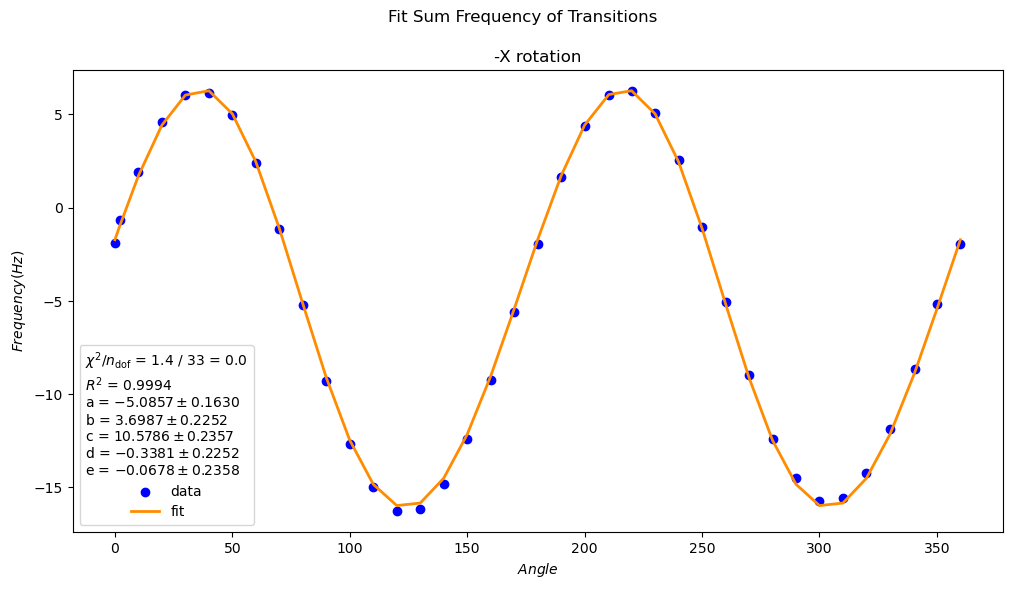

a = -5.085676272500975
b = 3.69866042832501
c = 10.57857958695116
d = -0.3380924374385633
e = -0.06777113932929467
R squared: 0.9946710678819777
┌───┬──────────────────────────────────────────────┐
│   │        a        b        c        d        e │
├───┼──────────────────────────────────────────────┤
│ a │        1  -0.0347  0.00846  -0.0314   0.0165 │
│ b │  -0.0347        1   0.0117  -0.0436   0.0229 │
│ c │  0.00846   0.0117        1   0.0106 -0.00558 │
│ d │  -0.0314  -0.0436   0.0106        1   0.0207 │
│ e │   0.0165   0.0229 -0.00558   0.0207        1 │
└───┴──────────────────────────────────────────────┘
Chi square: 7.007027923081575
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 7.007 (chi2/ndof = 0.2)    │              Nfcn = 172              │
│ EDM = 5.36e-23 (Goal: 0.0002)    │        

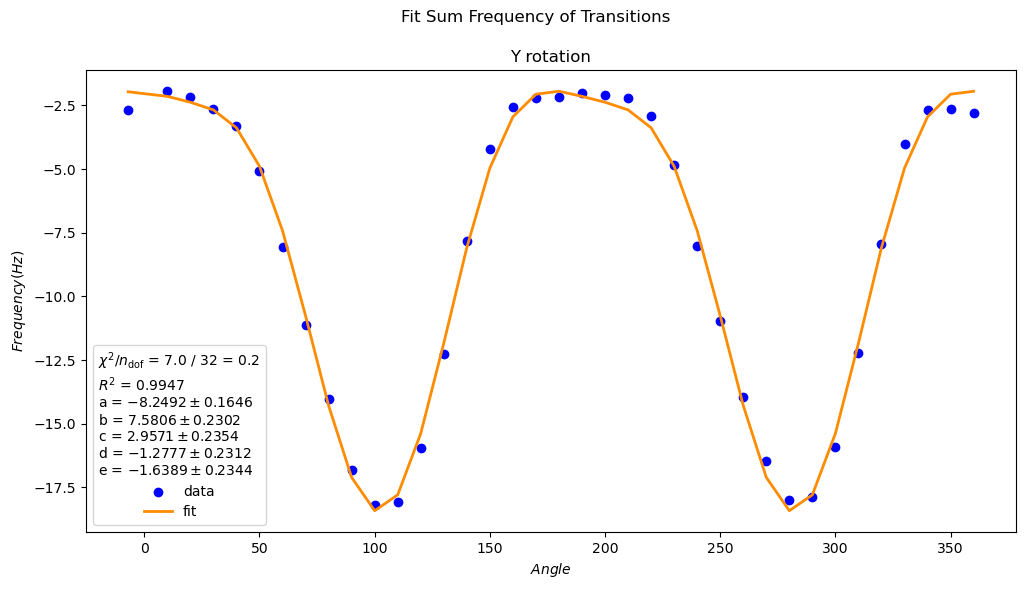

a = -8.249219013257715
b = 7.580579217175861
c = 2.9571194722431957
d = -1.2776583193951625
e = -1.6389092215886654
R squared: 0.9985346584075362
┌───┬───────────────────────────────────────────────────┐
│   │         a         b         c         d         e │
├───┼───────────────────────────────────────────────────┤
│ a │         1   -0.0356   0.00019    -0.037  0.000141 │
│ b │   -0.0356         1  0.000116   -0.0499 -3.33e-05 │
│ c │   0.00019  0.000116         1 -0.000277  -0.00111 │
│ d │    -0.037   -0.0499 -0.000277         1  0.000414 │
│ e │  0.000141 -3.33e-05  -0.00111  0.000414         1 │
└───┴───────────────────────────────────────────────────┘
Chi square: 0.963609841244703
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0.9636 (chi2/ndof = 0.0)   │              Nfcn = 170              

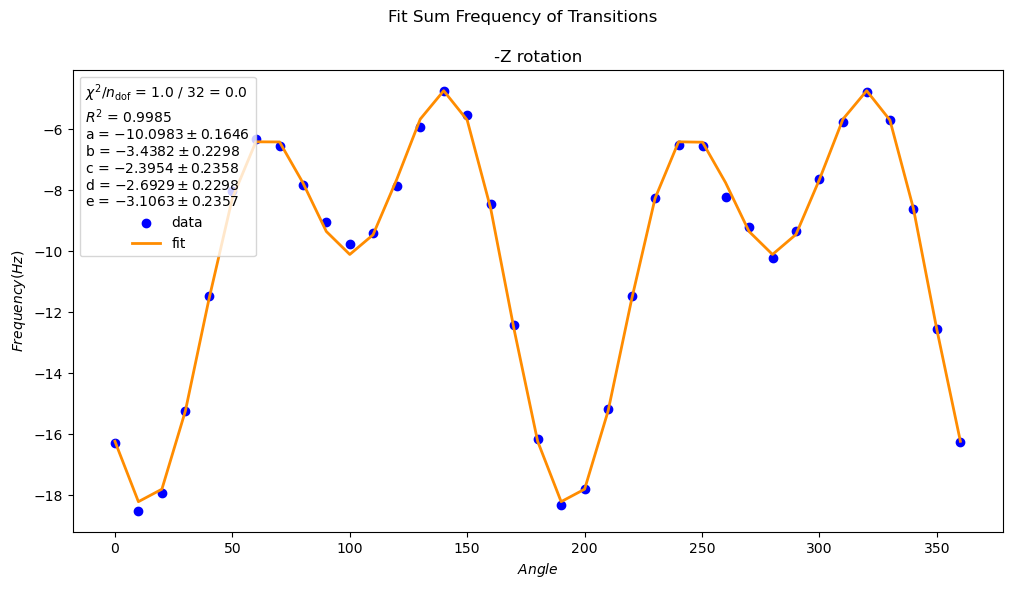

a = -10.098321722425418
b = -3.4381575318237063
c = -2.3953846560969585
d = -2.6928939020132563
e = -3.1062747630451475


In [6]:
m_s = [0]*3
corr_mat = [0]*3

for i in range(3):
    least_squares = LeastSquares(df[i].Angle, freq_sum[i], 1, fourier5)
    
    m_s[i] = Minuit(least_squares, a = 1, b = 1, c= 1, d = 0, e = 1).migrad()
    # m[i] = m[i].scan(ncall = 50)

    m_s[i].migrad()  # finds minimum of least_squares function
    m_s[i].hesse()   # accurately computes uncertainties
    
    fit_info = [
    f"$\\chi^2$/$n_\\mathrm{{dof}}$ = {m_s[i].fval:.1f} / {m_s[i].ndof:.0f} = {m_s[i].fmin.reduced_chi2:.1f}",
    ]
    # print(fit_info)
    # Calculate R squared
    y_true = freq_sum[i]
    y_pred = fourier5(df[i].Angle, *m_s[i].values)
    SST = np.sum((y_true - np.mean(y_true))**2)
    SSR = np.sum((y_true - y_pred)**2)
    R_squared = 1 - (SSR / SST)
    print(f"R squared: {R_squared}")
    # plt.imshow(corr_mat, cmap='coolwarm')
        # Append R squared to fit_info
    fit_info.append(f"$R^2$ = {R_squared:.4f}")
    
    for p, v, e in zip(m_s[i].parameters, m_s[i].values, m_s[i].errors):
        fit_info.append(f"{p} = ${v:.4f} \\pm {e:.4f}$")

    corr_mat = (m_s[i].covariance.correlation())
    print(corr_mat)
    print('Chi square:', m_s[i].fval)
    print(m_s[i].migrad())


    # draw data and fitted line
    # m_s[i].draw_mnmatrix("a", "e", cl=(0.68, 0.9, 0.99));
    # plt.show()
    plt.figure(figsize=(12, 6))
    plt.scatter(df[i].Angle, freq_sum[i], label="data", color = 'blue')
    plt.plot(df[i].Angle, fourier5(df[i].Angle, *m_s[i].values), label="fit", lw = 2, color = 'darkorange')
    plt.xlabel(r'$Angle$')
    plt.ylabel(r'$Frequency (Hz)$')
    # Titles
    plt.suptitle('Fit Sum Frequency of Transitions')
    plt.title(titles[i])
    plt.legend(title="\n".join(fit_info))
    # plt.grid()
    plt.show()
    
    for key, value in zip(m_s[i].parameters, m_s[i].values):
        print(f"{key} = {value}")

In [7]:
# # from IPython.display import display

# # angle_data = df[2].Angle
# # freq_diff_data = freq_diff[2]

# # # Creating the DataFrame

# # data = {'Angle': angle_data, 'Frequency Difference': freq_diff_data}
# # data_z = pd.DataFrame(data)

# # # Displaying the DataFrame
# # display(data_z)

# # # Indices of points to be removed (replace with actual indices)
# angles_to_remove = [90, 100, 109.9, 120, 130, 140, 270, 280, 290]  
# assert len(df[2].Angle) == len(freq_diff[2]), "Length mismatch between df[2].Angle and freq_diff[2]"
# removed_angles = np.isin(df[2].Angle, angles_to_remove)
# df[2].Angle = df[2].Angle[~removed_angles].reset_index(drop=True)
# freq_diff[2] = freq_diff[2][~removed_angles].reset_index(drop=True)

# print(freq_diff[2])

# print(df[2].Angle, freq_diff[2])
# # # Creating the DataFrame with filtered data
# # data_removed = {'Angle': df[2].Angle, 'Frequency Difference': freq_diff[2]}
# # data_removed_z = pd.DataFrame(data_removed)

# # display(data_removed_z)

In [8]:

# Box Plot

# import seaborn as sns
# sns.boxplot(freq_diff[2])


R squared: 0.998977053178341


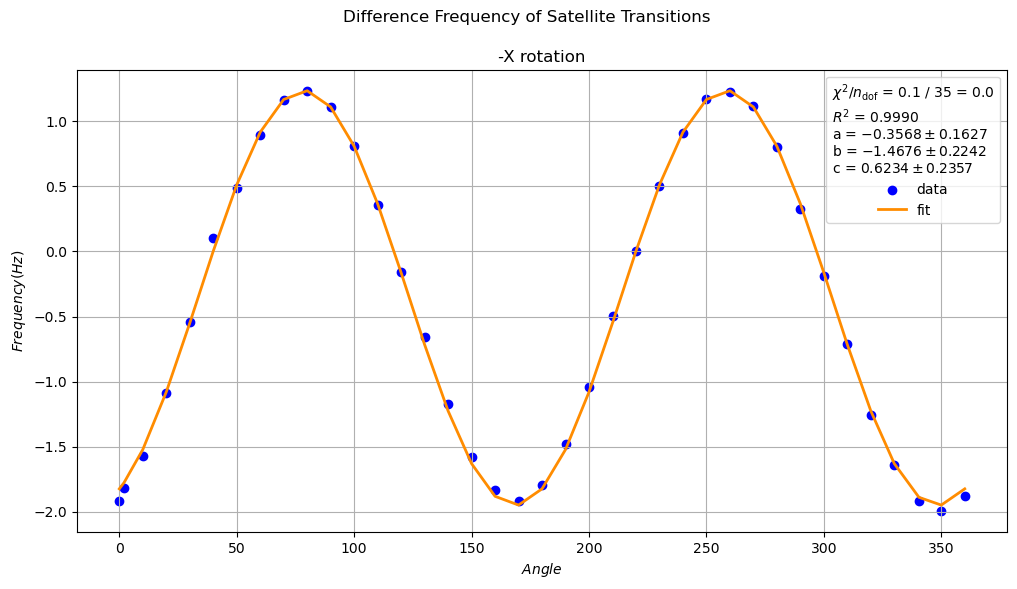

a = -0.3567882528852738
b = -1.4676302938371986
c = 0.6234088581937633
R squared: 0.9916103810984193


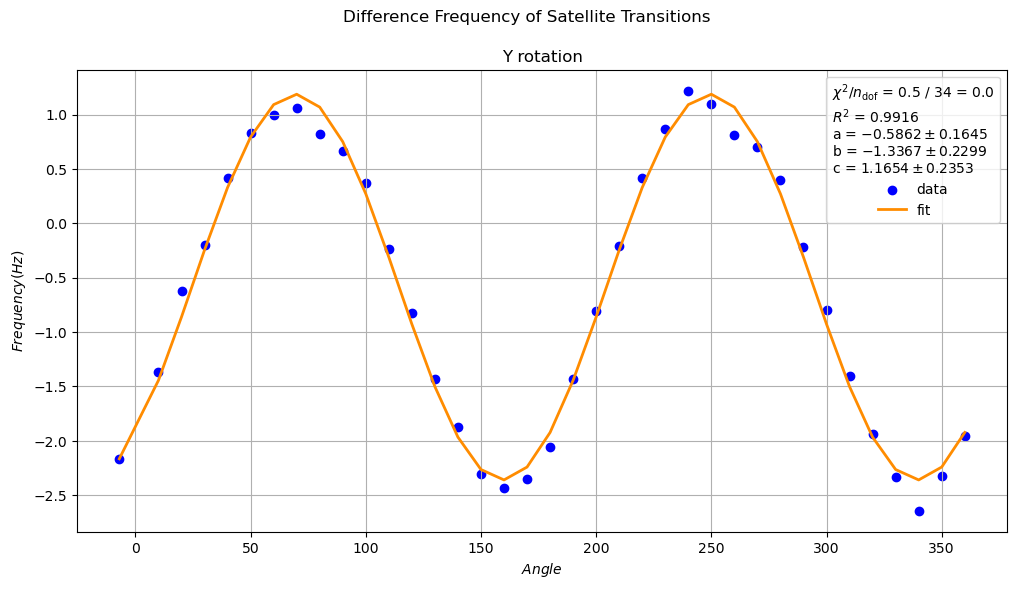

a = -0.5862016067752643
b = -1.3366851305703455
c = 1.1654352912680137
R squared: 0.8335134607602235


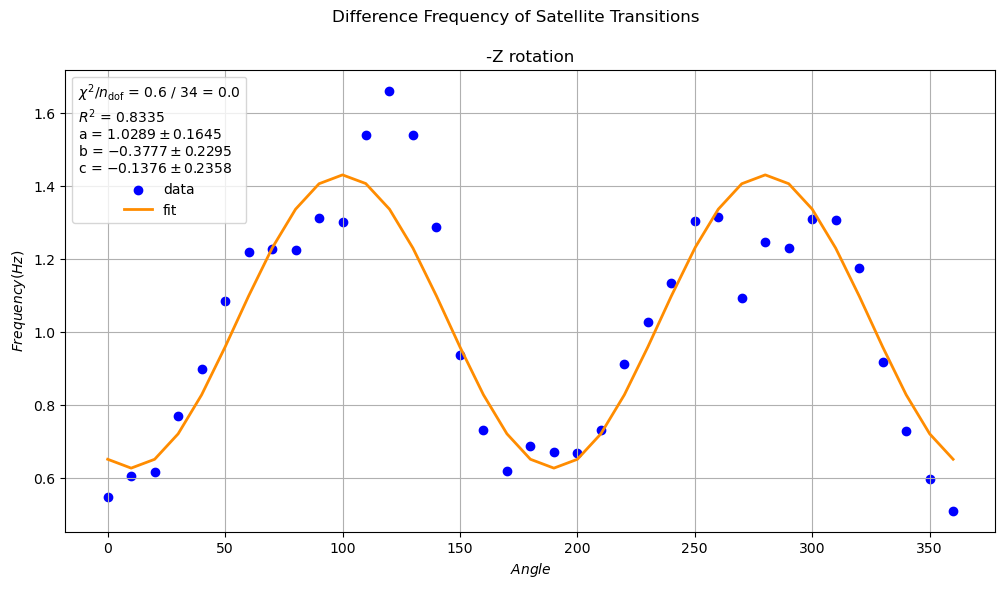

a = 1.0289336850391095
b = -0.3776563589702807
c = -0.13756611347974892


In [9]:
m_d = [0]*3

for i in range(3):
    least_squares = LeastSquares(df[i].Angle, freq_diff[i], 1,fourier3)
    m_d[i] = Minuit(least_squares, a = 1, b = 1, c= 1)
    # m_d[i] = Minuit(least_squares, a = 10, b = 10, c= 10)
    # m_d[i].fixed["c"] = True
    # m_d[i].fixed["b"] = True
    # m[i] = m[i].scan(ncall = 50)

    m_d[i].migrad()  # finds minimum of least_squares function
    m_d[i].hesse()   # accurately computes uncertainties
    fit_info = [
    f"$\\chi^2$/$n_\\mathrm{{dof}}$ = {m_d[i].fval:.1f} / {m_d[i].ndof:.0f} = {m_d[i].fmin.reduced_chi2:.1f}",
    ]
    # print(fit_info)
    
    # Calculate R squared
    y_true = freq_diff[i]
    y_pred = fourier3(df[i].Angle, *m_d[i].values)
    SST = np.sum((y_true - np.mean(y_true))**2)
    SSR = np.sum((y_true - y_pred)**2)
    R_squared = 1 - (SSR / SST)
    print(f"R squared: {R_squared}")

    # plt.imshow(corr_mat, cmap='coolwarm')
    
        # Append R squared to fit_info
    fit_info.append(f"$R^2$ = {R_squared:.4f}")

    for p, v, e in zip(m_d[i].parameters, m_d[i].values, m_d[i].errors):
        fit_info.append(f"{p} = ${v:.4f} \\pm {e:.4f}$")

    corr_mat = (m_d[i].covariance.correlation())
    # print(corr_mat)
    # print(m_d[i].migrad())
    # plt.imshow(corr_mat, cmap='coolwarm')
    
    # draw data and fitted line
    plt.figure(figsize=(12, 6))
    plt.scatter(df[i].Angle, freq_diff[i], label="data", color = 'blue')
    plt.plot(df[i].Angle, fourier3(df[i].Angle, *m_d[i].values), label="fit", lw = 2, color = 'darkorange')
    # plt.plot(df[i].angle, HQ1[i], label = 'input ')
    plt.xlabel(r'$Angle$')
    plt.ylabel(r'$Frequency (Hz)$')
    # Title
    plt.suptitle('Difference Frequency of Satellite Transitions')
    plt.title(titles[i])
    plt.legend(title="\n".join(fit_info))
    plt.grid()
    plt.show()
    
    for key, value in zip(m_d[i].parameters, m_d[i].values):
        print(f"{key} = {value}")

**Find HQ Tensor**

In [10]:
a_s = [0]*3; a_d = [0]*3
b_s = [0]*3; b_d = [0]*3
c_s = [0]*3; c_d = [0]*3
d_s = [0]*3
e_s = [0]*3

par_s = [a_s, b_s, c_s, d_s, e_s]
par_d = [a_d, b_d, c_d]

for i in range(0,3):
    for k in range(len(par_s)):
        par_s[k][i] = m_s[i].values[k]
    for j in range(len(par_d)):
        par_d[j][i] = m_d[i].values[j]
# Quadrupolar coefficients
A_Q = [0]*3
B_Q = [0]*3
C_Q = [0]*3

# A_HQ1 = [0]*3
# B_HQ1 = [0]*3
# X = [0]*3
# # https://stackoverflow.com/questions/36354807/solving-linear-equations-w-three-variables-using-numpy

# for i in range(0,3):
#     A_HQ1[i] = np.array([[1/2, 1/2], [1/2, -1/2]])
#     B_HQ1[i] = np.array([a_d[i], b_d[i]])
#     X[i] = np.linalg.inv(A_HQ1[i]).dot(B_HQ1[i])

# gzz_q1 = X[0][0]
# gyy_q1= X[0][1]

gyz_q = -c_d[0]

# gzz_q2 = X[1][0]
# gxx_q2 = X[1][1]
gxz_q = c_d[1]

# gxx_q3 = X[2][0]
# gyy_q3 = X[2][1]
gxy_q = -c_d[2]
gzz_q1 = (2*a_d[0] + 2*b_d[0])/2
gyy_q1 = (2*a_d[0] - 2*b_d[0])/2

gzz_q2 = (2*a_d[1] + 2*b_d[1])/2
gxx_q2 = (2*a_d[1] - 2*b_d[1])/2

gxx_q3 = (2*a_d[2] + 2*b_d[2])/2
gyy_q3 = (2*a_d[2] - 2*b_d[2])/2

print(gxx_q2, gxx_q3,gyy_q1, gyy_q3, gzz_q1, gzz_q2 )
gxx_q = np.mean([gxx_q2, gxx_q3])
gyy_q = np.mean([gyy_q1, gyy_q3])
gzz_q = np.mean([gzz_q1, gzz_q2])




QXG_f = np.zeros((3, 3))                                #Tensor from fitting
QXG_f[0,0]=gxx_q; QXG_f[0,1]=gxy_q; QXG_f[0,2]=gxz_q;
QXG_f[1,0]=gxy_q; QXG_f[1,1]=gyy_q; QXG_f[1,2]=gyz_q;
QXG_f[2,0]=gxz_q; QXG_f[2,1]=gyz_q; QXG_f[2,2]=gzz_q;

#    Plot to check that difference frequency is mostly HQ1
#    plt.plot(df[i].angle, HQ1[i], label = 'HQ1')
#    plt.plot(df[i].angle, df[i].freq_diff, label = 'diff frequency')
#    plt.legend()
#    plt.show()


print('Calculated Quad Tensor:\n',QXG_f)


0.7504835237950812 0.6512773260688288 1.1108420409519248 1.4065900440093904 -1.8244185467224723 -1.92288673734561
Calculated Quad Tensor:
 [[ 0.70088042  0.13756611  1.16543529]
 [ 0.13756611  1.25871604 -0.62340886]
 [ 1.16543529 -0.62340886 -1.87365264]]


In [11]:
# A = np.array([gzz_q + gyy_q, gzz_q + gxx_q, gxx_q + gyy_q])*1/2
# B = np.array([gzz_q - gyy_q, gzz_q - gxx_q, gxx_q - gyy_q ])*1/2
# C = np.array([-gyz_q, gxz_q, -gxy_q])

# HQ1= [0]*3

# for i in range(3):
#    HQ1[i] = a_d[i] + b_d[i]*np.cos(2*df[i].Angle*np.pi/180.) + c_d[i]*np.cos(2*df[i].Angle*np.pi/180.) 

#    #Plot to check that difference frequency is mostly HQ1
#    plt.plot(df[i].Angle, HQ1[i], label = 'HQ1')
#    plt.plot(df[i].Angle, freq_diff[i], label = 'diff frequency')
#    plt.legend()
#    plt.show()

**Find HQ1 and HQ2**

In [12]:
HQ1_freq_3212 = [0]*3
HQ1_freq_1212 = [0]*3
HQ1_freq_1232 = [0]*3


HQ2_freq_3212 = [0]*3
HQ2_freq_1212 = [0]*3
HQ2_freq_1232 = [0]*3

for i in range (3):
    ang = df[i].Angle*np.pi/180.
    atheta = [-ang, ang,np.pi/2 ] #-x, y, -z rotation
    aphi = [np.pi/2, 0, -ang]

    theta = atheta[i] 
    phi = aphi[i]
    ct = np.cos(theta); st = np.sin(theta); s2t = 2*ct*st; c2t = ct*ct-st*st;
    cp = np.cos(phi); sp = np.sin(phi); s2p = 2*cp*sp; c2p = cp*cp-sp*sp;

    R2m2Q, R2m1Q, R20Q, R2p1Q, R2p2Q = Quad(QXG_f,ct, st, s2t, c2t, cp ,sp ,c2p ,s2p)

            
    HQ1 = 1/(2*Ispin*(2*Ispin-1))*R20Q
    HQ2a= (0.5/(2*Ispin*(2*Ispin-1))**2)*(R2m2Q*R2p2Q)/wX                         
    HQ2b = (0.5/(2*Ispin*(2*Ispin-1))**2)*(R2m1Q*R2p1Q)/wX


    HQ1_freq_3212[i] = 6*(np.real(HQ1))               # 3/2 <-> 1/2
    HQ1_freq_1212[i] = 0*(np.real(HQ1))               # 1/2 <-> -1/2
    HQ1_freq_1232[i] = -6*(np.real(HQ1))              #-1/2   <-> -3/2       
    
    HQ2_freq_3212[i] = 0*np.real(HQ2a) + -12*np.real(HQ2b)       # 3/2 <-> 1/2
    HQ2_freq_1212[i] = 6*np.real(HQ2a) + 12*np.real(HQ2b)        # 1/2 <-> -1/2
    HQ2_freq_1232[i] = 0*np.real(HQ2a) + -12*np.real(HQ2b)       #-1/2   <-> -3/2                                                                          


# len(HQ_freq_3212[0])
# len(df[0].freq_3212)

# print(HQ_freq_3212[0])

# HQ1_3212 = 1/4*(gzz_q + gxx_q + (gzz_q - gxx_q)*np.cos(2*df[i].angle*np.pi/180.) + 2*gxz_q*np.cos(2*df[i].angle*np.pi/180.))
# HQ1_1212 = 0
# HQ1_1232 = -1/4*(gzz_q + gxx_q + (gzz_q - gxx_q)*np.cos(2*df[i].angle*np.pi/180.) + 2*gxz_q*np.cos(2*df[i].angle*np.pi/180.))

**Verify Tensor Components from HQ2**

In [13]:
Dx = (-21/16*(gzz_q - gyy_q)**2 + 21/4*gyz_q**2)/(72*wX)
Ex = 21/4*(gzz_q - gyy_q)*gyz_q/(72*wX)

Dy = (-21/16*(gzz_q - gxx_q)**2 + 21/4*gxz_q**2)/(72*wX)
Ey = (-21/4*gxz_q*(gzz_q - gxx_q))/(72*wX)

Dz = (-21/16*(gxx_q - gyy_q)**2 + 21/4*gxy_q**2)/(72*wX)
Ez = (21/4*gxy_q*(gxx_q - gyy_q))/(72*wX)

table = [['Dx', d_s[0], Dx],  ['Ex', e_s[0], Ex],['Dy', d_s[1], Dy],  ['Ey', e_s[1], Ey], ['Dz', d_s[2], Dz],  ['Ez', e_s[2], Ez]]
print(tabulate(table, headers=['Coefficient','Coefficients from fit', 'Calculated coefficients']))

Coefficient      Coefficients from fit    Calculated coefficients
-------------  -----------------------  -------------------------
Dx                          -0.338092                -7.81727e-10
Ex                          -0.0677711                7.39485e-10
Dy                          -1.27766                 -1.13158e-10
Ey                          -1.63891                  1.13624e-09
Dz                          -2.69289                 -2.22937e-11
Ez                          -3.10627                 -2.90604e-11


**Find CSA Tensor**

R squared: 0.9983479671727155
┌───┬────────────────────────────┐
│   │        a        b        c │
├───┼────────────────────────────┤
│ a │        1  -0.0725 -0.00313 │
│ b │  -0.0725        1 -0.00333 │
│ c │ -0.00313 -0.00333        1 │
└───┴────────────────────────────┘
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.783 (chi2/ndof = 0.1)    │              Nfcn = 86               │
│ EDM = 5.39e-21 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼─────

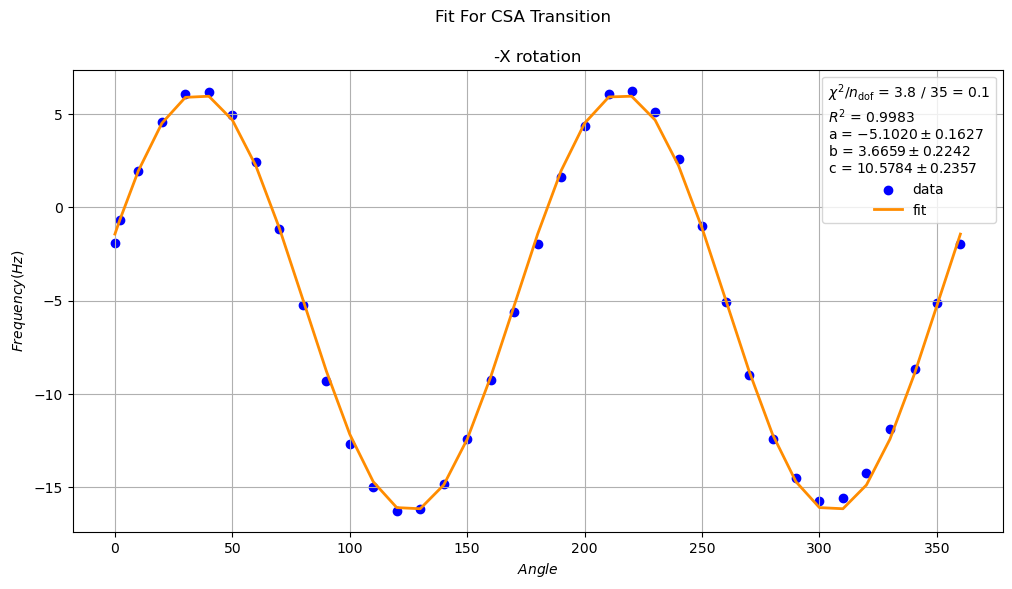

a = -5.102043999523142
b = 3.6658828654030278
c = 10.578237535233441
R squared: 0.9354647349488756
┌───┬─────────────────────────┐
│   │       a       b       c │
├───┼─────────────────────────┤
│ a │       1 -0.0365  0.0089 │
│ b │ -0.0365       1  0.0124 │
│ c │  0.0089  0.0124       1 │
└───┴─────────────────────────┘
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 84.86 (chi2/ndof = 2.5)    │              Nfcn = 86               │
│ EDM = 1.37e-21 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit      

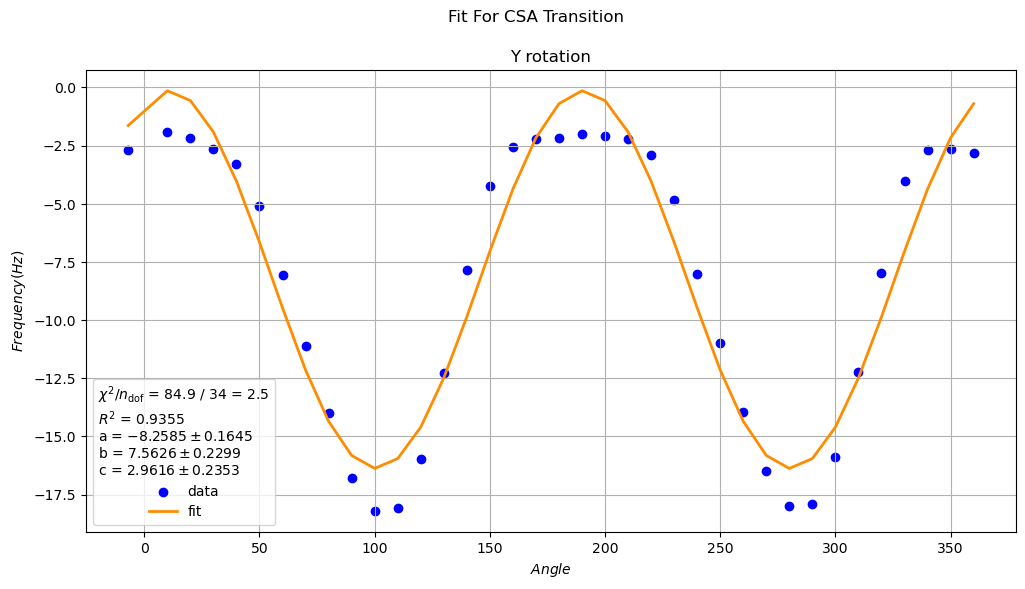

a = -8.25841604258946
b = 7.562731545087307
c = 2.961569396355059
R squared: 0.5259503440861539
┌───┬────────────────────────────┐
│   │        a        b        c │
├───┼────────────────────────────┤
│ a │        1  -0.0375  0.00018 │
│ b │  -0.0375        1 0.000102 │
│ c │  0.00018 0.000102        1 │
└───┴────────────────────────────┘
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 311.7 (chi2/ndof = 9.2)    │              Nfcn = 80               │
│ EDM = 9.02e-23 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Belo

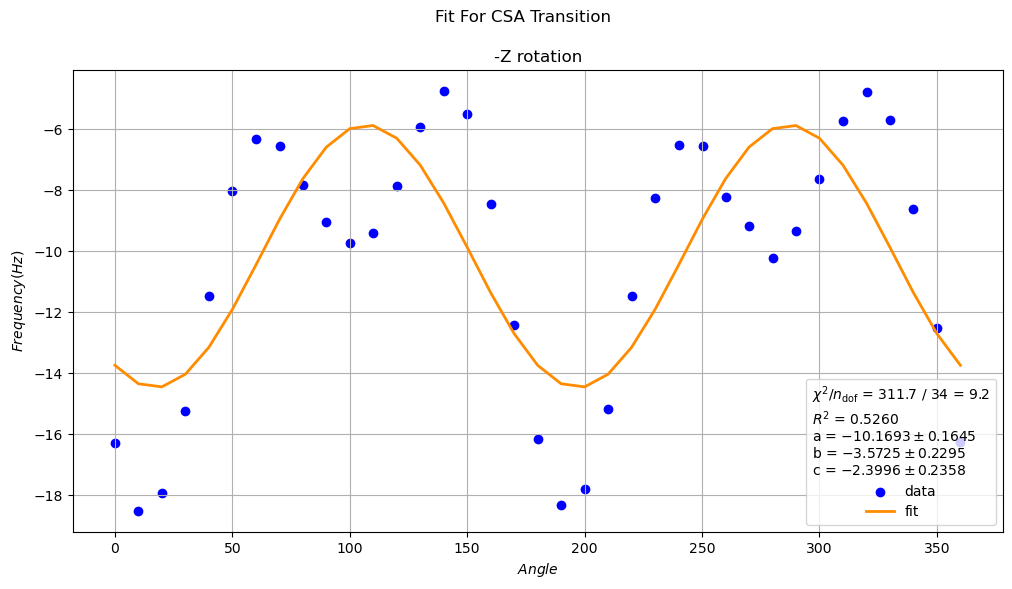

a = -10.169329680935332
b = -3.572473595850709
c = -2.399600033486578


In [14]:
HQ2_freq_sum = [0]*3
csa = [0]*3
# y_csa[0] = np.subtract(f_s[0], HQ2[0]) 
# print(f_s[0], HQ2[0], y_csa[0])
# 
for i in range(3):
    HQ2_freq_sum[i] = HQ2_freq_3212[i] + HQ2_freq_1212[i] + HQ2_freq_1232[i]
    csa[i] = freq_sum[i] - HQ2_freq_sum[i]


# HQ2_freq_sum = [0]*3
m_csa = [0]*3
# y_csa = [0]*3
# y_csa[0] = np.subtract(f_s[0], HQ2[0]) 
# print(f_s[0], HQ2[0], y_csa[0])
# 
for i in range(0,3):
    # HQ2_freq_sum[i] = HQ2_freq_3212[i] + HQ2_freq_1212[i] + HQ2_freq_1232[i]
    # y_csa[i] = np.subtract(df[i].freq_sum, HQ2_freq_sum[i])    
    # y_csa[i] = np.subtract(df[i].freq_sum, HQ2[i]) 
    least_squares = LeastSquares(df[i].Angle, csa[i], 1,fourier3)
    
    m_csa[i] = Minuit(least_squares, a = -1, b = -1, c= -1)
    # m[i] = m[i].scan(ncall = 50)

    m_csa[i].migrad()  # finds minimum of least_squares function
    m_csa[i].hesse()   # accurately computes uncertainties
    fit_info = [
    f"$\\chi^2$/$n_\\mathrm{{dof}}$ = {m_csa[i].fval:.1f} / {m_csa[i].ndof:.0f} = {m_csa[i].fmin.reduced_chi2:.1f}",
    ]
    # print(fit_info)

        # Calculate R squared
    y_true = csa[i]
    y_pred = fourier3(df[i].Angle, *m_csa[i].values)
    SST = np.sum((y_true - np.mean(y_true))**2)
    SSR = np.sum((y_true - y_pred)**2)
    R_squared = 1 - (SSR / SST)
    print(f"R squared: {R_squared}")

    # plt.imshow(corr_mat, cmap='coolwarm')
    
        # Append R squared to fit_info
    fit_info.append(f"$R^2$ = {R_squared:.4f}")

    for p, v, e in zip(m_csa[i].parameters, m_csa[i].values, m_csa[i].errors):
        fit_info.append(f"{p} = ${v:.4f} \\pm {e:.4f}$")

    corr_mat = (m_csa[i].covariance.correlation())
    print(corr_mat)
    print(m_csa[i].migrad())
    
   
    
    # draw data and fitted line
    plt.figure(figsize=(12, 6))
    plt.scatter(df[i].Angle, csa[i], label="data", color = 'blue')
    plt.plot(df[i].Angle, fourier3(df[i].Angle, *m_csa[i].values), label="fit", lw = 2, color = 'darkorange')
    plt.xlabel(r'$Angle$')
    plt.ylabel(r'$Frequency (Hz)$')
    # Title
    plt.suptitle('Fit For CSA Transition')
    plt.title(titles[i])
    plt.legend(title="\n".join(fit_info))
    plt.grid()
    plt.show()
    
    for key, value in zip(m_csa[i].parameters, m_csa[i].values):
        print(f"{key} = {value}")

a_csa = [0]*3; 
b_csa = [0]*3; 
c_csa = [0]*3; 

par_csa = [a_csa, b_csa, c_csa]

for i in range(0,3):
    for k in range(len(par_csa)):
        par_csa[k][i] = m_csa[i].values[k]


In [15]:
A= [0]*3
B = [0]*3
C = [0]*3
A_HCSA1 = [0]*3
B_HCSA1 = [0]*3
X = [0]*3


for i in range(0,3):

    A_HCSA1[i] = np.array([[3/2, 3/2], [3/2, -3/2]])
    B_HCSA1[i] = np.array([a_csa[i], b_csa[i]])
    X[i] = np.linalg.inv(A_HCSA1[i]).dot(B_HCSA1[i])
    

gzz_csa1 = X[0][0]
gyy_csa1= X[0][1]
gyz_csa = -c_csa[0]/3

gzz_csa2 = X[1][0]
gxx_csa2 = X[1][1]
gxz_csa = c_csa[1]/3

gxx_csa3 = X[2][0]
gyy_csa3 = X[2][1]
gxy_csa = -c_csa[2]/3

gxx_csa = np.mean([gxx_csa2, gxx_csa3])
gyy_csa = np.mean([gyy_csa1, gyy_csa3])
gzz_csa = np.mean([gzz_csa1, gzz_csa2])




CsaQXG_f = np.zeros((3, 3))                                #Tensor from fitting
CsaQXG_f[0,0]=gxx_csa; CsaQXG_f[0,1]=gxy_csa; CsaQXG_f[0,2]=gxz_csa;
CsaQXG_f[1,0]=gxy_csa; CsaQXG_f[1,1]=gyy_csa; CsaQXG_f[1,2]=gyz_csa;
CsaQXG_f[2,0]=gxz_csa; CsaQXG_f[2,1]=gyz_csa; CsaQXG_f[2,2]=gzz_csa;


print(gxx_csa2, gxx_csa3, gyy_csa1, gyy_csa3, gzz_csa1, gzz_csa2)
print('Calculated CSA Tensor:\n',CsaQXG_f)


print(tabulate([['gxx_q',gxx_q], ['gyy_q',gyy_q], ['gzz_q',gzz_q], ['gxy_q',gxy_q], ['gyz_q',gyz_q], ['gxz_q',gxz_q],['gxx_csa',gxx_csa], ['gyy_csa',gyy_csa], ['gzz_csa',gzz_csa], ['gxy_csa',gxy_csa], ['gyz_csa',gyz_csa], ['gxz_csa',gxz_csa]]))

-5.273715862558922 -4.580601092262014 -2.922642288308723 -2.198952028361541 -0.47872037804003803 -0.23189483250071743
Calculated CSA Tensor:
 [[-4.92715848  0.79986668  0.9871898 ]
 [ 0.79986668 -2.56079716 -3.52607918]
 [ 0.9871898  -3.52607918 -0.35530761]]
-------  ---------
gxx_q     0.70088
gyy_q     1.25872
gzz_q    -1.87365
gxy_q     0.137566
gyz_q    -0.623409
gxz_q     1.16544
gxx_csa  -4.92716
gyy_csa  -2.5608
gzz_csa  -0.355308
gxy_csa   0.799867
gyz_csa  -3.52608
gxz_csa   0.98719
-------  ---------


In [16]:
eigenvalues, eigenvectors = np.linalg.eig(QXG_f)
D_quad = np.diag(eigenvalues)
print('Diagonalized Quadrupolar Tensor:\n', D_quad)
sorted_eigenvalues = sorted(eigenvalues, key=abs)


print('Sorted Eigenvalues of Quadrupolar diagonal matrix:\n', sorted_eigenvalues) #See Haberlen convention for details [ref: Single-Crystal NMR Spectroscopy – Method Development and Application to Inorganic Solids]

Gzz_q = sorted_eigenvalues[2]
Gyy_q = sorted_eigenvalues[1]
Gxx_q = sorted_eigenvalues[0]

print('Quad Tensors Gzz_q, Gyy_q, Gxx_q (According to |Qzz| >= |Qyy| >= |Qxx|): \n', Gzz_q, Gyy_q, Gxx_q)

print('================================================================================================')

eigenvalues, eigenvectors = np.linalg.eig(CsaQXG_f)
D_csa = np.diag(eigenvalues)

print('Diagonalized CSA Tensor:\n',D_csa)
csa_avg = np.mean(eigenvalues)

sorted_eigenvalues = sorted((eigenvalues - csa_avg), key = abs) #See Haberlen convention for details

print('Sorted Eigenvalues (Eigenvalue + isotropic CS)  of CSA diagonal matrix:\n',sorted_eigenvalues )

Gzz_csa = sorted_eigenvalues[2] + csa_avg
Gxx_csa = sorted_eigenvalues[1] + csa_avg 
Gyy_csa = sorted_eigenvalues[0] + csa_avg

print('CSA Tensors Gzz_csa, Gyy_csa, Gxx_csa (According to |Gzz - isotropic| >= |Gxx - isotropic| >= |Gyy - isotropic|) : \n', Gzz_csa, Gyy_csa, Gxx_csa)

Diagonalized Quadrupolar Tensor:
 [[-2.43089433  0.          0.        ]
 [ 0.          1.11472806  0.        ]
 [ 0.          0.          1.40211009]]
Sorted Eigenvalues of Quadrupolar diagonal matrix:
 [1.1147280600610312, 1.4021100919413167, -2.4308943266237764]
Quad Tensors Gzz_q, Gyy_q, Gxx_q (According to |Qzz| >= |Qyy| >= |Qxx|): 
 -2.4308943266237764 1.4021100919413167 1.1147280600610312
Diagonalized CSA Tensor:
 [[-6.27970259  0.          0.        ]
 [ 0.         -3.81484151  0.        ]
 [ 0.          0.          2.25128085]]
Sorted Eigenvalues (Eigenvalue + isotropic CS)  of CSA diagonal matrix:
 [-1.2004204287709141, -3.6652815054779437, 4.865701934248858]
CSA Tensors Gzz_csa, Gyy_csa, Gxx_csa (According to |Gzz - isotropic| >= |Gxx - isotropic| >= |Gyy - isotropic|) : 
 2.251280853910196 -3.8148415091095766 -6.279702585816606


In [17]:
# #for CSA
# Siso_fit = (gxx_csa + gyy_csa + gzz_csa)/3
# Siso_ppm_fit = Siso_fit/w0
# delta_fit = gzz_csa/w0 - Siso_ppm_fit
# eta_fit = (gxx_csa - gyy_csa)/w0/delta_fit

# #for Quadrupolar
# CQ_fit = gzz_q*(2*Ispin*(2*Ispin - 1))/10**6
# Qeta_fit = (gxx_q - gyy_q)/gzz_q

# table = [['Siso (ppm)',Siso_ppm_fit ],['delta (ppm)', delta_fit],  ['eta', eta_fit],  ['CQ (MHz)', CQ_fit], ['Qeta', Qeta_fit ]]
# print(tabulate(table, headers=['Qauntity', 'Fit Value']))

#****************************************************************

#using Diagonalized values 
# for CSA
Siso_fit = (Gxx_csa + Gyy_csa + Gzz_csa)/3
Siso_ppm_fit = Siso_fit/w0
delta_fit = Gzz_csa/w0 - Siso_ppm_fit
eta_fit = (Gyy_csa - Gxx_csa)/w0/delta_fit

#for Quadrupolar
CQ_fit = Gzz_q*(2*Ispin*(2*Ispin - 1))/10**6
Qeta_fit = (Gxx_q - Gyy_q)/Gzz_q

table = [['Siso (ppm)',Siso_ppm_fit ],['delta (ppm)', delta_fit],  ['eta', eta_fit],  ['CQ (MHz)', CQ_fit], ['Qeta', Qeta_fit ]]
print(tabulate(table, headers=['Qauntity', 'Fit Value']))

Qauntity        Fit Value
-----------  ------------
Siso (ppm)   -0.0135779
delta (ppm)   0.0252698
eta           0.506579
CQ (MHz)     -1.45854e-05
Qeta          0.118221
